<a href="https://colab.research.google.com/github/chamarairesh1982/ml-cybersecurity/blob/main/section1_phishing/section1_phishing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 1 — Phishing email triage
**Independent learning lab • self-contained Google Colab notebook**

Run the cells in order. This notebook loads public data directly into the Colab runtime, never your local machine. It needs no uploaded dataset, separate Python file, Drive mount, credential, or other notebook.

**Question:** can email text help prioritise corpus-labelled phishing while controlling false alerts? A benchmark result does not prove current real-world phishing detection.

**Workflow:** problem → provenance → raw audit → cleaning → duplicate grouping → split → training-only EDA → feature engineering → grouped cross-validation → classical/ensemble comparison → neural model → validation threshold → one final test → uncertainty/error analysis → compact evidence.

No results are pre-filled. Only running the notebook produces measurements.

## Lecture concepts applied
| Learning topic | How this notebook uses it |
|---|---|
| 1: ML foundations | Prediction target, baseline, generalisation, over/underfitting |
| 2: preparation and EDA | Types, missing/empty values, class balance, length and quality audit |
| 3: feature engineering | Word/character TF-IDF, structural features, training-only scaling |
| 4–5: supervised learning | Regularised logistic regression and linear SVM |
| 6–7: neural networks | Trainable embeddings, dense layers, dropout, early stopping |
| 8: ensembles | Random forest on interpretable structural features |
| 9: evaluation | Same splits, grouped CV, tuning, confusion/PR/ROC, operating point |
| 10: unsupervised learning | Reserved primarily for the later anomaly scenario; not forced into this supervised task |
| 11: deep learning | Simple baseline comparison, class weights, validation learning curves |
| 12: NLP | Tokenisation, n-grams, TF-IDF, stemming ablation, embeddings |

We apply the relevant concepts rather than every algorithm indiscriminately. Splitting occurs before **learned** preprocessing, even when slides present splitting at the end of a conceptual preparation list. No lecture content or school identifiers are bundled.

## 1. Runtime and reproducibility
Choose **Runtime → Change runtime type** in Colab. Classical models run on CPU regardless of accelerator. The neural model supports TensorFlow GPU or TPU strategies, with integer sequences prepared on CPU before training. GPU is often sufficient for this corpus. TPU compatibility is implemented but must be verified on your actual runtime.

Use the default full experiment for evidence. A smaller smoke run tests code only; do not compare its scores with a full run. Changing configuration defines a new experiment and requires a new untouched test set for subsequent development.

In [1]:
# Colab already includes the major scientific packages.
# Install only the small extras needed for near-duplicate grouping and NLP.
%pip -q install "datasketch>=1.6,<2" "nltk>=3.9,<4" "requests>=2.31,<3"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.9/99.9 kB 3.7 MB/s eta 0:00:00


In [2]:
import os, re, io, json, time, random, hashlib, platform, html
from pathlib import Path
from joblib import Memory
from collections import Counter
import importlib.metadata as metadata
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, confusion_matrix, precision_recall_curve,
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay)
from nltk.stem import SnowballStemmer
from datasketch import MinHash, MinHashLSH

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
RUN_NEURAL = True
ACCELERATOR = "auto"  # auto, cpu, gpu, or tpu. Explicit TPU failures stop clearly.
CV_FOLDS = 3
N_JOBS = 2  # Avoid duplicating large TF-IDF matrices across too many workers.
CACHE_FEATURES = True
FEATURE_CACHE_DIR = "/content/section1_feature_cache"  # Temporary Colab storage only.
RUN_LEARNING_CURVE = False  # Optional, computationally expensive training diagnostic.
MAX_TEXT_CHARS = 20000
NEAR_DUPLICATE_JACCARD = 0.85
MINHASH_PERMUTATIONS = 128
TARGET_FPR = 0.01  # Illustrative 1% legitimate-message false-alert budget.
BOOTSTRAPS = 300
EPOCHS = 12
VOCAB_SIZE = 20000
SEQUENCE_LENGTH = 512
DATASET_REVISION = "34085a032c123ca237f314a01a67909cdea35e34"
DATA_URL = ("https://huggingface.co/datasets/zefang-liu/phishing-email-dataset/"
            f"resolve/{DATASET_REVISION}/Phishing_Email.csv")
EXPECTED_SHA256 = "18ef4fff1acb8986f0ab01e83ede6025420c829656af5a377560fce17e153b97"
LABEL_MAP = {"Safe Email": 0, "Phishing Email": 1}
versions = {p: metadata.version(p) for p in
            ["numpy", "pandas", "scikit-learn", "matplotlib", "datasketch", "nltk", "joblib"]}
print("Python:", platform.python_version(), "\nPackages:", versions)
print("No personal identifiers or credentials are required.")

Python: 3.13.15 
Packages: {'numpy': '2.1.3', 'pandas': '2.2.3', 'scikit-learn': '1.6.1', 'matplotlib': '3.10.0', 'datasketch': '1.10.0', 'nltk': '3.9.1', 'joblib': '1.6.0'}
No personal identifiers or credentials are required.


## 2. Public dataset and its limitations
Use the [Phishing Email Dataset mirror](https://huggingface.co/datasets/zefang-liu/phishing-email-dataset), attributed by its card to the [original Kaggle dataset](https://www.kaggle.com/datasets/subhajournal/phishingemails). The mirror lists LGPL-3.0. Preserve attribution and check the provider's rights before redistribution; this repository distributes **code only**.

The pinned CSV is about 52 MB and exposes `Email Text` and `Email Type`. We check these fields and exact label strings at runtime. Ignore exported row indexes. Metadata do not establish reliable campaign IDs, time ordering, or independently adjudicated phishing labels. Results therefore measure **this corpus's labels**, not operational safety. Dataset choice prioritises accessible text, transparent loading, and reproducibility; it is not claimed to be the world's best corpus.

The CSV is parsed as data, never executed. Raw email text is not displayed or exported. HTTPS download, pinned revision and SHA-256 verify identity. All fetching happens only when you run this cell in Colab.

In [3]:
def load_public_csv(url, expected_sha256):
    response = requests.get(url, timeout=(20, 180))
    response.raise_for_status()
    payload = response.content
    digest = hashlib.sha256(payload).hexdigest()
    if digest != expected_sha256:
        raise ValueError("Dataset checksum mismatch. Investigate the provider before changing the pin.")
    frame = pd.read_csv(io.BytesIO(payload))
    return frame, digest, len(payload)

raw, dataset_sha256, download_bytes = load_public_csv(DATA_URL, EXPECTED_SHA256)
required = {"Email Text", "Email Type"}
if not required.issubset(raw.columns):
    raise ValueError(f"Expected fields missing: {sorted(required - set(raw.columns))}")
print("Downloaded into runtime memory:", download_bytes, "bytes")
print("SHA-256:", dataset_sha256)

Downloaded into runtime memory: 52034604 bytes
SHA-256: 18ef4fff1acb8986f0ab01e83ede6025420c829656af5a377560fce17e153b97


## 3. Raw profiling before cleaning
Review dimensions, types, missing values, class labels and text lengths without displaying messages. Do not use test-label distributions to choose model settings. This initial audit validates schema and data quality; detailed model-oriented EDA follows the split on training data.

In [4]:
display(pd.DataFrame({"dtype": raw.dtypes.astype(str),
                       "missing": raw.isna().sum()}))
print("Rows:", len(raw), "columns:", len(raw.columns))
label_counts = raw["Email Type"].value_counts(dropna=False)
display(label_counts.rename("count").to_frame())
unknown = set(raw["Email Type"].dropna().unique()) - set(LABEL_MAP)
if unknown:
    raise ValueError(f"Unrecognised labels: {unknown}; investigate, do not guess mappings.")
raw_lengths = raw["Email Text"].fillna("").astype(str).str.len()
display(raw_lengths.describe(percentiles=[.5, .9, .95, .99]).to_frame("characters"))

,dtype,missing
Unnamed: 0,int64,0
Email Text,object,16
Email Type,object,0


Rows: 18650 columns: 3


,count
Email Type,
Safe Email,11322
Phishing Email,7328


,characters
count,1.865000e+04
mean,2.753290e+03
std,1.248141e+05
min,0.000000e+00
50%,8.800000e+02
90%,3.812300e+03
95%,6.354200e+03
99%,1.565452e+04
max,1.703669e+07


## 4. Conservative cleaning with an audit trail
Drop missing labels/text and empty or sentinel text. Decode HTML entities, remove script/style and HTML tags, normalise Unicode and whitespace. Preserve ordinary punctuation, numbers, URLs and negation for useful features. Exact duplicates are recognised **before** character truncation; remove all copies with contradictory labels, then retain one copy of consistent duplicates.

Report excessively long messages and cap their model input, not their labels. Do not impute a missing email with a fabricated body. Stemming and stopword removal are tested later as an ablation rather than assumed helpful.

In [5]:
import unicodedata

def clean_text(value):
    value = unicodedata.normalize("NFKC", html.unescape(str(value)))
    value = re.sub(r"<(script|style)\b[^>]*>.*?</\1\s*>", " ", value,
                   flags=re.I | re.S)
    value = re.sub(r"<[^>]+>", " ", value)
    return re.sub(r"\s+", " ", value).strip()

def prepare_data(frame):
    audit = {"raw_rows": len(frame)}
    data = frame[["Email Text", "Email Type"]].copy()
    missing = data.isna().any(axis=1)
    audit["missing_rows_removed"] = int(missing.sum())
    data = data.loc[~missing].copy()
    data["text"] = data["Email Text"].map(clean_text)
    empty = data["text"].str.casefold().isin(["", "empty", "nan", "none", "null"])
    audit["empty_or_sentinel_rows_removed"] = int(empty.sum())
    data = data.loc[~empty].copy()
    data["label"] = data["Email Type"].map(LABEL_MAP)
    if data["label"].isna().any():
        raise ValueError("Invalid labels after mapping.")
    data["label"] = data["label"].astype("int32")
    data["exact_hash"] = data["text"].str.casefold().map(
        lambda t: hashlib.sha256(t.encode("utf-8")).hexdigest())
    conflicting = data.groupby("exact_hash")["label"].nunique()
    conflict_keys = conflicting[conflicting > 1].index
    bad = data["exact_hash"].isin(conflict_keys)
    audit["contradictory_duplicate_rows_removed"] = int(bad.sum())
    data = data.loc[~bad].copy()
    audit["consistent_duplicate_rows_removed"] = int(data["exact_hash"].duplicated().sum())
    data = data.drop_duplicates("exact_hash").reset_index(drop=True)
    data["full_characters"] = data["text"].str.len()
    audit["truncated_messages"] = int((data["full_characters"] > MAX_TEXT_CHARS).sum())
    data["text"] = data["text"].str.slice(0, MAX_TEXT_CHARS)
    audit["retained_rows"] = len(data)
    if data["label"].nunique() != 2 or data["label"].value_counts().min() < 30:
        raise ValueError("Too few usable examples per class.")
    return data[["text", "label", "exact_hash", "full_characters"]], audit

data, cleaning_audit = prepare_data(raw)
del raw  # Avoid retaining an unnecessary full raw-data copy.
display(pd.Series(cleaning_audit).to_frame("count"))

,count
raw_rows,18650
missing_rows_removed,16
empty_or_sentinel_rows_removed,536
contradictory_duplicate_rows_removed,0
consistent_duplicate_rows_removed,585
truncated_messages,85
retained_rows,17513


## 5. Group likely related messages before splitting
Template fingerprints replace URLs, addresses and digit strings, while MinHash LSH proposes pairs of similar five-word shingles. Verify actual Jaccard similarity before joining groups. The union-find groups keep discovered relatives together, including transitive matches.

This is an **approximate content-based proxy**, not real campaign ground truth. LSH can miss pairs. Short texts use whole-text shingles. Grouping is deterministic and label-free, over model-visible text, and does not fit a predictive vocabulary. No source/timestamp holdout is possible with this metadata. Record group size and acknowledge residual leakage.

In [6]:
def template_text(text):
    text = text.casefold()
    text = re.sub(r"https?://\S+|www\.\S+", " urltoken ", text)
    text = re.sub(r"\b[\w.+-]+@[\w.-]+\.[a-z]{2,}\b", " emailtoken ", text)
    text = re.sub(r"\d+", " numbertoken ", text)
    return " ".join(re.findall(r"\w+", text))

def shingles(text):
    tokens = template_text(text).split()
    if len(tokens) < 5:
        return {" ".join(tokens)}
    return {" ".join(tokens[i:i+5]) for i in range(len(tokens)-4)}

def build_content_groups(texts):
    parent = np.arange(len(texts))
    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return int(i)
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[max(ra, rb)] = min(ra, rb)
    lsh = MinHashLSH(threshold=NEAR_DUPLICATE_JACCARD,
                     num_perm=MINHASH_PERMUTATIONS)
    saved_shingles = []
    templates = {}
    verified_pairs = 0
    for i, text in enumerate(texts):
        template = template_text(text)
        if template in templates:
            union(i, templates[template])
        else:
            templates[template] = i
        pieces = shingles(text)
        signature = MinHash(num_perm=MINHASH_PERMUTATIONS, seed=SEED)
        signature.update_batch([p.encode("utf-8") for p in sorted(pieces)])
        for key in lsh.query(signature):
            j = int(key)
            other = saved_shingles[j]
            similarity = len(pieces & other) / max(1, len(pieces | other))
            if similarity >= NEAR_DUPLICATE_JACCARD:
                union(i, j)
                verified_pairs += 1
        lsh.insert(str(i), signature)
        saved_shingles.append(pieces)
        if (i + 1) % 2000 == 0:
            print("Grouping progress:", i + 1, "/", len(texts))
    return np.array([find(i) for i in range(len(texts))]), verified_pairs

data["group"], near_pairs = build_content_groups(data["text"].tolist())
group_sizes = data["group"].value_counts()
print("Groups:", len(group_sizes), "verified similar pairs:", near_pairs)
display(group_sizes.describe().to_frame("group_size"))
if len(group_sizes) < 20:
    raise ValueError("Insufficient independent content groups for this split design.")

Grouping progress: 2000 / 17513
Grouping progress: 4000 / 17513
Grouping progress: 6000 / 17513
Grouping progress: 8000 / 17513
Grouping progress: 10000 / 17513
Grouping progress: 12000 / 17513
Grouping progress: 14000 / 17513
Grouping progress: 16000 / 17513
Groups: 16533 verified similar pairs: 11732


,group_size
count,16533.000000
mean,1.059275
std,1.169102
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,137.000000


## 6. Freeze train, validation and test partitions
Use fixed folds from a seven-fold stratified group split: five folds for training, one validation and one test (approximately 71/14/14; group sizes affect proportions). Do not optimise the split for a higher score. The same partitions serve every model.

Cross-validation operates **only within training**. Validation chooses the model/operating threshold and neural stopping epoch. Final test is untouched until all decisions are frozen. Never oversample before splitting.

In [7]:
def make_partitions(frame):
    y = frame["label"].to_numpy()
    groups = frame["group"].to_numpy()
    splitter = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
    folds = [test for _, test in splitter.split(frame["text"], y, groups)]
    train_idx = np.concatenate(folds[:5])
    val_idx, test_idx = folds[5], folds[6]
    parts = {"train": train_idx, "validation": val_idx, "test": test_idx}
    for name, idx in parts.items():
        if len(np.unique(y[idx])) != 2:
            raise ValueError(f"{name} lacks a class; revise the experiment design.")
    for a, b in [("train", "validation"), ("train", "test"), ("validation", "test")]:
        assert not set(groups[parts[a]]) & set(groups[parts[b]])
        assert not set(frame.iloc[parts[a]]["exact_hash"]) & set(frame.iloc[parts[b]]["exact_hash"])
    return parts

partitions = make_partitions(data)
train_idx, val_idx, test_idx = [partitions[k] for k in ["train", "validation", "test"]]
X_train = data.iloc[train_idx]["text"].to_numpy()
y_train = data.iloc[train_idx]["label"].to_numpy()
g_train = data.iloc[train_idx]["group"].to_numpy()
X_val = data.iloc[val_idx]["text"].to_numpy()
y_val = data.iloc[val_idx]["label"].to_numpy()
# Do not construct test predictions or inspect test errors yet.
display(pd.DataFrame([{"partition": k, "rows": len(v),
                      "groups": data.iloc[v]["group"].nunique()}
                     for k,v in partitions.items()]))
cv = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED + 1)
cv_splits = list(cv.split(X_train, y_train, g_train))
for tr, va in cv_splits:
    assert not set(g_train[tr]) & set(g_train[va])
    if len(np.unique(y_train[tr])) != 2 or len(np.unique(y_train[va])) != 2:
        raise ValueError("A CV fold lacks a class; inspect grouping.")

,partition,rows,groups
0,train,12483,11781
1,validation,2499,2376
2,test,2531,2376


## 7. Training-only exploratory analysis
Inspect prevalence and message length. Long examples may be legitimate and should not be deleted merely as statistical outliers. Labels are provider claims; a statistical plot cannot verify them. Numerical predictors below are deterministic features available from an incoming message, not exported index/label fields.

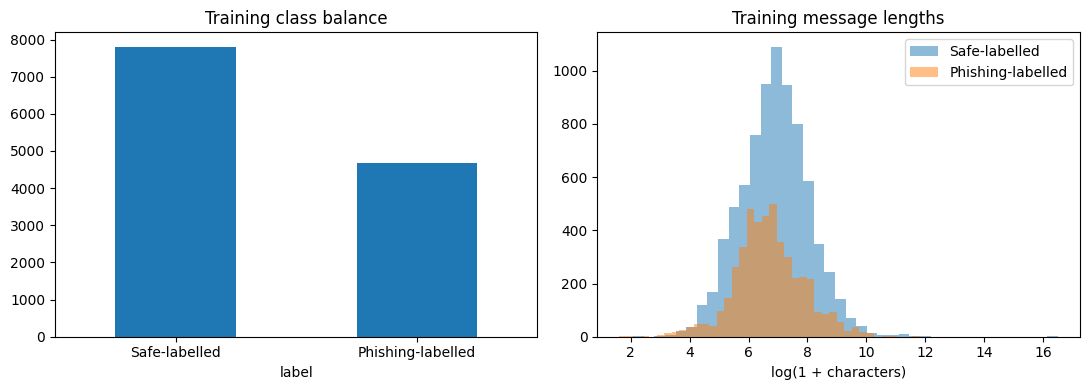

Training phishing prevalence: 0.3748
Character-capped training fraction: 0.005


In [8]:
training = data.iloc[train_idx]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
training["label"].value_counts().sort_index().plot.bar(ax=axes[0])
axes[0].set_xticklabels(["Safe-labelled", "Phishing-labelled"], rotation=0)
axes[0].set_title("Training class balance")
for label, name in [(0,"Safe-labelled"), (1,"Phishing-labelled")]:
    lengths = training.loc[training["label"] == label, "full_characters"]
    axes[1].hist(np.log1p(lengths), bins=40, alpha=.5, label=name)
axes[1].set_xlabel("log(1 + characters)"); axes[1].legend()
axes[1].set_title("Training message lengths")
plt.tight_layout(); plt.show()
print("Training phishing prevalence:", round(float(y_train.mean()), 4))
print("Character-capped training fraction:", round(float((training["full_characters"] > MAX_TEXT_CHARS).mean()), 4))

## 8. Feature engineering and preprocessing ablation
Word TF-IDF captures phrases; character TF-IDF tolerates spelling variants. Test a basic word model, a word+character representation, and a lecture-style stopword/stemming ablation. Preserve negation words in that ablation. Compare rather than automatically deleting useful text.

Structure features include length, URL/address counts and character ratios. Scaling is relevant to numerical linear models; a random forest does not require it. Do not densify the full sparse TF-IDF matrix. Every learned vocabulary, IDF weight and scale is fitted inside each CV training fold.

In [9]:
stemmer = SnowballStemmer("english")
stopwords = set(ENGLISH_STOP_WORDS) - {"not", "no", "nor", "never"}

def stemmed_tokens(text):
    words = re.findall(r"[a-z]+", text.casefold())
    return [stemmer.stem(word) for word in words if word not in stopwords]

class StructureFeatures(BaseEstimator, TransformerMixin):
    names = ["log_chars", "log_words", "url_count", "email_count",
             "digit_ratio", "uppercase_ratio", "exclamation_count", "currency_count"]
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        rows = []
        for text in X:
            size = max(1, len(text))
            rows.append([np.log1p(len(text)), np.log1p(len(text.split())),
                         len(re.findall(r"https?://|www\.", text, flags=re.I)),
                         len(re.findall(r"\b[\w.+-]+@[\w.-]+", text)),
                         sum(c.isdigit() for c in text)/size,
                         sum(c.isupper() for c in text)/size,
                         text.count("!"), len(re.findall(r"[$£€]", text))])
        return np.asarray(rows, dtype=np.float32)

def word_features():
    return TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=.995,
                          sublinear_tf=True, max_features=40000)

def combined_features():
    return FeatureUnion([
        ("word", word_features()),
        ("character", TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5),
         min_df=3, sublinear_tf=True, max_features=40000))])

class_weight_options = [None, "balanced"]
experiments = {
    "word_lr": (Pipeline([("features", word_features()),
        ("model", LogisticRegression(max_iter=2000, random_state=SEED))]),
        {"model__C":[.3, 1.0, 3.0], "model__class_weight":class_weight_options}),
    "word_char_lr": (Pipeline([("features", combined_features()),
        ("model", LogisticRegression(max_iter=2000, random_state=SEED))]),
        {"model__C":[.3, 1.0, 3.0], "model__class_weight":class_weight_options}),
    "word_char_svm": (Pipeline([("features", combined_features()),
        ("model", LinearSVC(max_iter=5000, random_state=SEED))]),
        {"model__C":[.3, 1.0, 3.0], "model__class_weight":class_weight_options}),
    "stemmed_lr": (Pipeline([("features", TfidfVectorizer(tokenizer=stemmed_tokens,
        token_pattern=None, lowercase=False, ngram_range=(1,2), min_df=2,
        max_features=40000, sublinear_tf=True)),
        ("model", LogisticRegression(max_iter=2000, random_state=SEED))]),
        {"model__C":[.3, 1.0], "model__class_weight":class_weight_options}),
    "structure_lr": (Pipeline([("features", StructureFeatures()),
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=SEED))]),
        {"model__C":[.3, 1.0], "model__class_weight":class_weight_options}),
    "structure_forest": (Pipeline([("features", StructureFeatures()),
        ("model", RandomForestClassifier(n_estimators=200, min_samples_leaf=3,
         n_jobs=1, random_state=SEED))]),
        {"model__max_depth":[8, None], "model__class_weight":class_weight_options})
}
# Cache fitted training transforms by parameters and fold inputs.
# Classifier settings can vary while reusing fold-specific TF-IDF.
# Sharing the cache lets word+character LR and SVM reuse fitted features.
# Validation/test use ordinary transform calls, never fits.
feature_memory = Memory(FEATURE_CACHE_DIR, verbose=0) if CACHE_FEATURES else None
# Notebook-defined tokenisers/transformers are not reliably pickleable
# by process-worker disk caches; cache only built-in TF-IDF families.
for name in ["word_lr", "word_char_lr", "word_char_svm"]:
    experiments[name][0].set_params(memory=feature_memory)
print("Feature cache:", FEATURE_CACHE_DIR if CACHE_FEATURES else "disabled")
print("Candidate families:", list(experiments))
print("No test data are used in feature fitting.")

Feature cache: /content/section1_feature_cache
Candidate families: ['word_lr', 'word_char_lr', 'word_char_svm', 'stemmed_lr', 'structure_lr', 'structure_forest']
No test data are used in feature fitting.


## 9. Tune classical candidates using grouped cross-validation
Average precision (AP) is the primary ranking metric, more informative than accuracy alone for imbalance. AP is not trapezoidal PR-AUC. Tune a bounded, declared search rather than repeatedly hunting for favourable test results.

The structure forest demonstrates ensemble learning; it is not assumed to outperform sparse text classifiers. Fit a prior baseline as a minimum comparator. Record both training and CV scores to expose overfitting.

The three built-in word/character TF-IDF families cache feature extraction in temporary Colab storage, separately for each training fold and feature configuration. This reuses training matrices across classifier settings and the two word+character models without sharing fitted vocabulary between folds. Notebook-defined stemming/structural transforms remain uncached to avoid process-worker pickle failures. Validation and test still use transform-only calls. Grids and models are unchanged. The cache contains dataset-derived features and metadata; keep it in the temporary runtime and do not publish it. It trades runtime disk space for less repeated computation; set `CACHE_FEATURES=False` to disable it. First population and concurrent misses still incur work; actual speedup needs a fresh Colab measurement. GPU/TPU does not accelerate scikit-learn TF-IDF or these classifiers.


In [10]:
def model_scores(model, texts):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(texts)[:, 1]
    return model.decision_function(texts)

models, validation_scores, cv_records, fit_seconds = {}, {}, [], {}
baseline = DummyClassifier(strategy="prior").fit(np.zeros((len(y_train),1)), y_train)
models["prior"] = baseline
validation_scores["prior"] = baseline.predict_proba(np.zeros((len(y_val),1)))[:,1]
fit_seconds["prior"] = 0.0
for name, (pipeline, grid) in experiments.items():
    print("Training:", name)
    started = time.perf_counter()
    search = GridSearchCV(pipeline, grid, cv=cv_splits, scoring="average_precision",
                          n_jobs=N_JOBS, refit=True, return_train_score=True,
                          error_score="raise")
    search.fit(X_train, y_train)
    fit_seconds[name] = time.perf_counter() - started
    models[name] = search.best_estimator_
    validation_scores[name] = model_scores(models[name], X_val)
    best = search.best_index_
    cv_records.append({"model":name, "CV_AP":search.best_score_,
        "CV_AP_std":search.cv_results_["std_test_score"][best],
        "train_AP":search.cv_results_["mean_train_score"][best],
        "validation_AP":average_precision_score(y_val, validation_scores[name]),
        "search_seconds":fit_seconds[name], "best_params":search.best_params_})
cv_table = pd.DataFrame(cv_records).sort_values("CV_AP", ascending=False)
display(cv_table)

Training: word_lr
Training: word_char_lr
Training: word_char_svm
Training: stemmed_lr
Training: structure_lr
Training: structure_forest


,model,CV_AP,CV_AP_std,train_AP,validation_AP,search_seconds,best_params
2,word_char_svm,0.997361,0.000853,1.000000,0.998727,559.531204,"{'model__C': 1.0, 'model__class_weight': None}"
1,word_char_lr,0.996966,0.001116,0.999712,0.996681,673.468814,"{'model__C': 3.0, 'model__class_weight': 'bala..."
0,word_lr,0.995368,0.001386,0.999458,0.996762,133.915599,"{'model__C': 3.0, 'model__class_weight': 'bala..."
3,stemmed_lr,0.994009,0.001531,0.998533,0.996445,319.048139,"{'model__C': 1.0, 'model__class_weight': None}"
5,structure_forest,0.839849,0.010687,0.968584,0.846627,135.159994,"{'model__class_weight': None, 'model__max_dept..."
4,structure_lr,0.735035,0.019292,0.735782,0.740970,111.704280,"{'model__C': 1.0, 'model__class_weight': None}"


## 10. Optional learning curve
This diagnostic uses the highest CV-scoring classical family and only training folds. Grouped fold boundaries are respected, though smaller training prefixes can have noisier balance. A widening train/CV gap suggests variance; uniformly weak scores suggest insufficient representation or underfitting. Enable before final evaluation.

In [11]:
if RUN_LEARNING_CURVE:
    classical_cv_winner = cv_table.iloc[0]["model"]
    sizes, train_scores, heldout_scores = learning_curve(
        clone(models[classical_cv_winner]), X_train, y_train,
        cv=cv_splits, train_sizes=[.4,.7,1.0], scoring="average_precision",
        n_jobs=N_JOBS, shuffle=True, random_state=SEED)
    plt.plot(sizes, train_scores.mean(axis=1), "o-", label="Train")
    plt.plot(sizes, heldout_scores.mean(axis=1), "o-", label="CV")
    plt.xlabel("Training examples"); plt.ylabel("Average precision")
    plt.legend(); plt.title("Training-only learning curve"); plt.show()
else:
    print("Learning curve disabled; enable RUN_LEARNING_CURVE for this diagnostic.")

Learning curve disabled; enable RUN_LEARNING_CURVE for this diagnostic.


## 11. Neural comparator: embeddings + multilayer network
This applies embedding and MLP concepts from the neural/NLP lectures. A padding-aware average of learned token embeddings feeds dense layers. Dropout and early stopping control overfitting. Unlike an LSTM, this representation does not model word order; the classical word bigrams already provide an order-aware comparator.

Use a frozen train-only vocabulary. Convert text to integer sequences **outside** TPU execution, then train the numerical model inside the strategy scope. Measure truncation and OOV coverage. Train two fixed seeds to show optimisation variation. Both use the same partition and declared architecture. Select the seed/epoch using validation evidence only.

Strategy: MirroredStrategy replicas: 1
Training tokenised length > sequence cap: 0.17135304013458302
Validation OOV fraction: 0.08354699416435668
Epoch 1/12
391/391 - 10s - 26ms/step - loss: 0.2469 - pr_auc: 0.9654 - val_loss: 0.1029 - val_pr_auc: 0.9897
Epoch 2/12
391/391 - 3s - 8ms/step - loss: 0.0584 - pr_auc: 0.9962 - val_loss: 0.0787 - val_pr_auc: 0.9932
Epoch 3/12
391/391 - 4s - 10ms/step - loss: 0.0359 - pr_auc: 0.9984 - val_loss: 0.0713 - val_pr_auc: 0.9939
Epoch 4/12
391/391 - 3s - 8ms/step - loss: 0.0245 - pr_auc: 0.9995 - val_loss: 0.0749 - val_pr_auc: 0.9932
Epoch 5/12
391/391 - 3s - 8ms/step - loss: 0.0183 - pr_auc: 0.9996 - val_loss: 0.0677 - val_pr_auc: 0.9931
Epoch 6/12
391/391 - 3s - 8ms/step - loss: 0.0150 - pr_auc: 0.9995 - val_loss: 0.0660 - val_pr_auc: 0.9953
Epoch 7/12
391/391 - 4s - 10ms/step - loss: 0.0122 - pr_auc: 0.9997 - val_loss: 0.0740 - val_pr_auc: 0.9932
Epoch 8/12
391/391 - 3s - 8ms/step - loss: 0.0101 - pr_auc: 0.9995 - val_loss: 0.0680 - val_pr_auc: 0

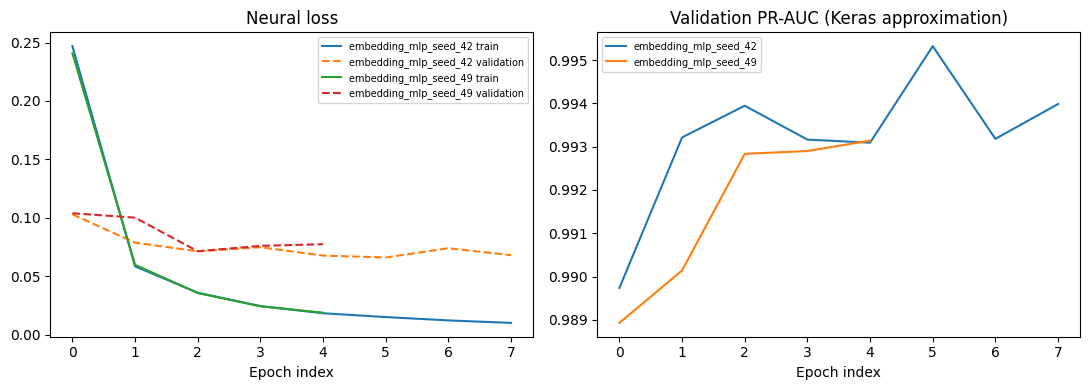

In [12]:
if RUN_NEURAL:
    import tensorflow as tf
    versions["tensorflow"] = tf.__version__
    if ACCELERATOR not in {"auto","cpu","gpu","tpu"}:
        raise ValueError("Unknown ACCELERATOR setting.")
    strategy = None
    if ACCELERATOR in {"auto","tpu"}:
        try:
            resolver = tf.distribute.cluster_resolver.TPUClusterResolver()
        except ValueError:
            if ACCELERATOR == "tpu":
                raise RuntimeError("TPU requested but not found. Select a TPU Colab runtime.")
        else:
            tf.config.experimental_connect_to_cluster(resolver)
            tf.tpu.experimental.initialize_tpu_system(resolver)
            strategy = tf.distribute.TPUStrategy(resolver)
    if strategy is None:
        gpus = tf.config.list_logical_devices("GPU")
        if ACCELERATOR == "gpu" and not gpus:
            raise RuntimeError("GPU requested but not found. Change the Colab runtime.")
        strategy = (tf.distribute.MirroredStrategy() if gpus and ACCELERATOR != "cpu"
                    else tf.distribute.OneDeviceStrategy("/CPU:0"))
    print("Strategy:", type(strategy).__name__, "replicas:", strategy.num_replicas_in_sync)

    # All string operations occur on CPU, not TPU.
    with tf.device("/CPU:0"):
        vectoriser = tf.keras.layers.TextVectorization(
            max_tokens=VOCAB_SIZE, standardize="lower_and_strip_punctuation",
            output_mode="int", output_sequence_length=SEQUENCE_LENGTH)
        vectoriser.adapt(tf.data.Dataset.from_tensor_slices(X_train).batch(128))
        def encode(texts):
            return np.concatenate([vectoriser(tf.constant(texts[i:i+128])).numpy()
                                   for i in range(0, len(texts), 128)]).astype("int32")
        train_tokens, val_tokens = encode(X_train), encode(X_val)
    print("Training tokenised length > sequence cap:",
          float(np.mean([len(re.findall(r"\S+", t)) > SEQUENCE_LENGTH for t in X_train])))
    print("Validation OOV fraction:",
          float((val_tokens == 1).sum()/max(1, (val_tokens != 0).sum())))

    @tf.keras.utils.register_keras_serializable(package="LearningLab")
    class MaskedMean(tf.keras.layers.Layer):
        def call(self, inputs):
            embeddings, tokens = inputs
            mask = tf.cast(tf.not_equal(tokens, 0), embeddings.dtype)[..., None]
            return tf.reduce_sum(embeddings * mask, axis=1) / tf.maximum(
                tf.reduce_sum(mask, axis=1), tf.cast(1, embeddings.dtype))

    def make_neural_model():
        tokens = tf.keras.Input(shape=(SEQUENCE_LENGTH,), dtype="int32")
        embedded = tf.keras.layers.Embedding(len(vectoriser.get_vocabulary()), 64)(tokens)
        pooled = MaskedMean()([embedded, tokens])
        hidden = tf.keras.layers.Dense(64, activation="relu",
                    kernel_regularizer=tf.keras.regularizers.l2(1e-4))(pooled)
        hidden = tf.keras.layers.Dropout(.4)(hidden)
        output = tf.keras.layers.Dense(1, activation="sigmoid")(hidden)
        model = tf.keras.Model(tokens, output)
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                      loss="binary_crossentropy",
                      metrics=[tf.keras.metrics.AUC(curve="PR", name="pr_auc")])
        return model

    GLOBAL_BATCH = 32 * strategy.num_replicas_in_sync
    def numerical_dataset(tokens, labels=None, training=False):
        if labels is None:
            ds = tf.data.Dataset.from_tensor_slices(tokens)
        else:
            ds = tf.data.Dataset.from_tensor_slices((tokens, labels.astype("float32")))
        if training:
            ds = ds.shuffle(len(tokens), seed=SEED, reshuffle_each_iteration=True)
        # pad training to a full batch so TPU shapes stay static without dropping examples.
        if training:
            ds = ds.repeat().take(int(np.ceil(len(tokens)/GLOBAL_BATCH))*GLOBAL_BATCH)
        return ds.batch(GLOBAL_BATCH, drop_remainder=training).prefetch(tf.data.AUTOTUNE)

    weights = {int(k):len(y_train)/(2*int(v))
               for k,v in zip(*np.unique(y_train, return_counts=True))}
    neural_histories = {}
    for seed in [SEED, SEED + 7]:
        tf.keras.utils.set_random_seed(seed)
        with strategy.scope():
            neural = make_neural_model()
        start = time.perf_counter()
        history = neural.fit(numerical_dataset(train_tokens, y_train, True),
                    validation_data=numerical_dataset(val_tokens, y_val),
                    epochs=EPOCHS, class_weight=weights, verbose=2,
                    callbacks=[tf.keras.callbacks.EarlyStopping(
                        monitor="val_loss", patience=2, restore_best_weights=True)])
        name = f"embedding_mlp_seed_{seed}"
        fit_seconds[name] = time.perf_counter() - start
        models[name] = neural
        validation_scores[name] = neural.predict(numerical_dataset(val_tokens), verbose=0).ravel()
        neural_histories[name] = history.history
    fig, axes = plt.subplots(1,2,figsize=(11,4))
    for name, history in neural_histories.items():
        axes[0].plot(history["loss"], label=name+" train")
        axes[0].plot(history["val_loss"], linestyle="--", label=name+" validation")
        axes[1].plot(history["val_pr_auc"], label=name)
    axes[0].set_title("Neural loss"); axes[1].set_title("Validation PR-AUC (Keras approximation)")
    for ax in axes: ax.set_xlabel("Epoch index"); ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()
else:
    print("Neural experiment disabled. Classical workflow is still complete.")

## 12. Validation selection and a false-alert policy
Choose the candidate with the highest validation recall **under the declared FPR budget**, then validation AP, then lower fitting cost. This explicitly ties selection to analyst workload. SVM decision scores are ranking margins, not probabilities; do not label them calibrated risk probabilities.

For every classifier, find the feasible threshold with greatest recall; reject-all is always a feasible comparator. A 1% sample FPR is an empirical budget, not a guaranteed population bound. No model is retrained on validation after setting its threshold, because that would change score distributions. Freeze decisions before final evaluation.

In [13]:
def choose_threshold(y, scores, max_fpr):
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_y = np.asarray(scores)[order], np.asarray(y)[order]
    boundaries = np.r_[np.flatnonzero(np.diff(sorted_scores)), len(sorted_scores)-1]
    tp = np.cumsum(sorted_y)[boundaries]
    fp = (boundaries + 1) - tp
    tpr = tp / max(1, int(np.sum(y == 1)))
    fpr = fp / max(1, int(np.sum(y == 0)))
    thresholds = sorted_scores[boundaries]
    feasible = np.flatnonzero(fpr <= max_fpr)
    if not len(feasible):
        return float(np.nextafter(np.max(scores), np.inf)), 0.0, 0.0
    best = max(feasible, key=lambda i:(tpr[i], -fpr[i], thresholds[i]))
    return float(thresholds[best]), float(tpr[best]), float(fpr[best])

thresholds, validation_rows = {}, []
for name, scores in validation_scores.items():
    threshold, tpr, fpr = choose_threshold(y_val, scores, TARGET_FPR)
    thresholds[name] = threshold
    pred = scores >= threshold
    validation_rows.append({"model":name, "validation_recall":tpr, "validation_FPR":fpr,
        "validation_precision":precision_score(y_val,pred,zero_division=0),
        "validation_AP":average_precision_score(y_val,scores),
        "fit_seconds":fit_seconds[name], "threshold":threshold})
selection_table = pd.DataFrame(validation_rows).sort_values(
    ["validation_recall","validation_AP","fit_seconds"],
    ascending=[False,False,True])
display(selection_table)
winner = selection_table.iloc[0]["model"]
print("Frozen selected candidate:", winner)
experiment_config = {"seed":SEED,"target_FPR":TARGET_FPR,"winner":winner,
    "dataset_revision":DATASET_REVISION,"dataset_sha256":dataset_sha256,
    "max_text_chars":MAX_TEXT_CHARS,"near_duplicate_jaccard":NEAR_DUPLICATE_JACCARD,
    "cache_features":CACHE_FEATURES,"n_jobs":N_JOBS,
    "cv_folds":CV_FOLDS,"run_neural":RUN_NEURAL,"sequence_length":SEQUENCE_LENGTH,
    "neural_seeds":[SEED,SEED+7] if RUN_NEURAL else [],
    "max_epochs":EPOCHS,"vocabulary_cap":VOCAB_SIZE,
    "strategy":type(strategy).__name__ if RUN_NEURAL else "classical CPU"}
print("Only final evaluation below accesses held-out predictions.")

,model,validation_recall,validation_FPR,validation_precision,validation_AP,fit_seconds,threshold
3,word_char_svm,0.991295,0.009494,0.983801,0.998727,559.531204,-0.074392
1,word_lr,0.971708,0.009494,0.983480,0.996762,133.915599,0.590531
2,word_char_lr,0.969532,0.008228,0.985619,0.996681,673.468814,0.622114
4,stemmed_lr,0.959739,0.008861,0.984375,0.996445,319.048139,0.508397
7,embedding_mlp_seed_42,0.952122,0.008861,0.984252,0.995837,34.946414,0.858605
8,embedding_mlp_seed_49,0.952122,0.009494,0.983146,0.994068,16.960247,0.695823
6,structure_forest,0.260065,0.008861,0.944664,0.846627,135.159994,0.886045
5,structure_lr,0.188248,0.009494,0.920213,0.740970,111.704280,0.758313
0,prior,0.000000,0.000000,0.000000,0.367747,0.000000,0.374830


Frozen selected candidate: word_char_svm
Only final evaluation below accesses held-out predictions.


## 13. Final test — run once after decisions are frozen
Report all predeclared model families for comparison, while preserving the validation-selected winner. Do not switch the winner because a competitor happens to score better on this test. The test answers how frozen choices generalised.

A session guard blocks re-evaluating this cell. Restarting a runtime can bypass a guard, so experimental discipline remains necessary. To develop further after inspecting test results, use a new independent test set.

,model,selected_on_validation,accuracy,precision,recall,F1,AP,ROC_AUC,FPR,alerts_per_1000_legitimate,TN,FP,FN,TP,fit_seconds,test_seconds
0,prior,False,0.629395,0.000000,0.000000,0.000000,0.370605,0.500000,0.000000,0.000000,1593,0,938,0,0.000000,0.000331
1,word_lr,False,0.984196,0.988043,0.969083,0.978471,0.997510,0.998565,0.006905,6.905210,1582,11,29,909,133.915599,1.587875
2,word_char_lr,False,0.982616,0.984816,0.968017,0.976344,0.996068,0.997959,0.008788,8.788449,1579,14,30,908,673.468814,5.677748
3,word_char_svm,True,0.990913,0.985154,0.990405,0.987772,0.998188,0.998929,0.008788,8.788449,1579,14,9,929,559.531204,6.709122
4,stemmed_lr,False,0.979060,0.983607,0.959488,0.971398,0.996453,0.997916,0.009416,9.416196,1578,15,38,900,319.048139,2.670131
5,structure_lr,False,0.670486,0.757426,0.163113,0.268421,0.655281,0.797491,0.030760,30.759573,1544,49,785,153,111.704280,0.911281
6,structure_forest,False,0.706045,0.970874,0.213220,0.349650,0.832731,0.885267,0.003766,3.766478,1587,6,738,200,135.159994,0.994031
7,embedding_mlp_seed_42,False,0.977479,0.989989,0.948827,0.968971,0.992643,0.996533,0.005650,5.649718,1584,9,48,890,34.946414,0.667755
8,embedding_mlp_seed_49,False,0.977084,0.988889,0.948827,0.968444,0.992004,0.996740,0.006277,6.277464,1583,10,48,890,16.960247,0.625239


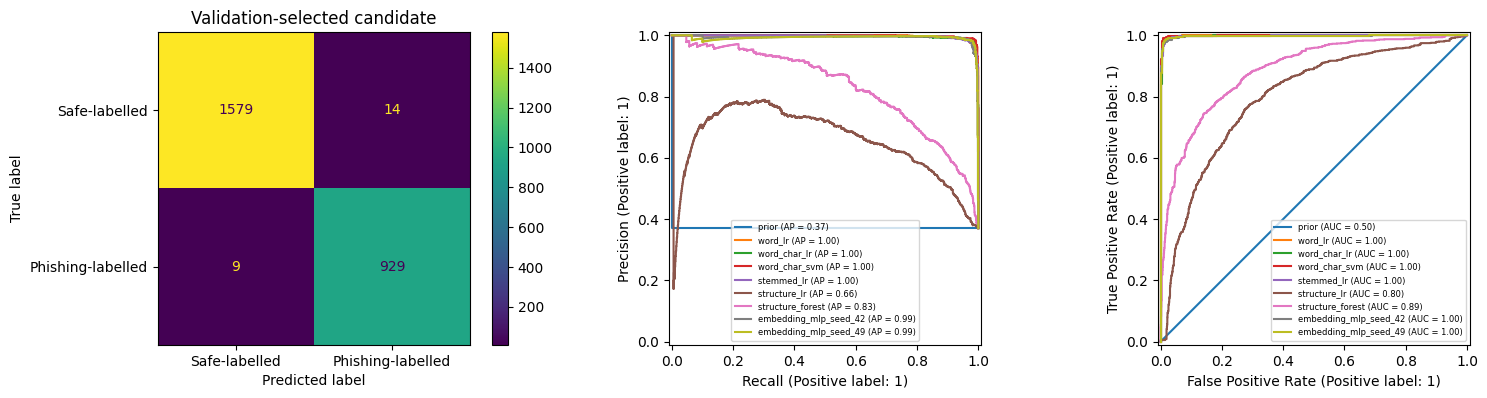

In [14]:
if globals().get("_test_evaluated", False):
    raise RuntimeError("Final test already evaluated in this session. Do not tune on it.")
_test_evaluated = True  # Claim the test before inspection, including failed/partial executions.
X_test = data.iloc[test_idx]["text"].to_numpy()
y_test = data.iloc[test_idx]["label"].to_numpy()
g_test = data.iloc[test_idx]["group"].to_numpy()
test_scores, test_rows = {}, []
if RUN_NEURAL:
    test_tokens = encode(X_test)
for name, model in models.items():
    started = time.perf_counter()
    if name == "prior":
        scores = model.predict_proba(np.zeros((len(y_test),1)))[:,1]
    elif name.startswith("embedding_mlp"):
        scores = model.predict(numerical_dataset(test_tokens), verbose=0).ravel()
    else:
        scores = model_scores(model, X_test)
    inference_seconds = time.perf_counter() - started
    test_scores[name] = scores
    predicted = (scores >= thresholds[name]).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test,predicted,labels=[0,1]).ravel()
    test_rows.append({"model":name,"selected_on_validation":name == winner,
        "accuracy":accuracy_score(y_test,predicted),
        "precision":precision_score(y_test,predicted,zero_division=0),
        "recall":recall_score(y_test,predicted,zero_division=0),
        "F1":f1_score(y_test,predicted,zero_division=0),
        "AP":average_precision_score(y_test,scores),"ROC_AUC":roc_auc_score(y_test,scores),
        "FPR":fp/max(1,fp+tn),"alerts_per_1000_legitimate":1000*fp/max(1,fp+tn),
        "TN":int(tn),"FP":int(fp),"FN":int(fn),"TP":int(tp),
        "fit_seconds":fit_seconds[name],"test_seconds":inference_seconds})
test_table = pd.DataFrame(test_rows)
display(test_table)
fig, axes = plt.subplots(1,3,figsize=(16,4))
winning_predictions = (test_scores[winner] >= thresholds[winner]).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test, winning_predictions,
    display_labels=["Safe-labelled","Phishing-labelled"], ax=axes[0])
for name,scores in test_scores.items():
    PrecisionRecallDisplay.from_predictions(y_test,scores,name=name,ax=axes[1])
    RocCurveDisplay.from_predictions(y_test,scores,name=name,ax=axes[2])
axes[0].set_title("Validation-selected candidate")
for ax in axes[1:]: ax.legend(fontsize=6)
plt.tight_layout(); plt.show()
winner_test = test_table.loc[test_table["model"] == winner].iloc[0]
if winner_test["FPR"] > TARGET_FPR:
    print("Held-out FPR exceeded the validation budget. Report this failure; do not retune on test.")

## 14. Group bootstrap uncertainty and safe error analysis
Resample whole content groups so discovered relatives remain together. These percentile intervals are conditional on this dataset/split/model and are not deployment guarantees. Group-size variability can widen intervals; missing-class replicates are excluded.

Inspect aggregate error patterns (length bins) instead of printing private messages. Neural seed differences estimate optimisation variation, not collection shift. Independent future/source data are still required.

In [15]:
def group_bootstrap(y, scores, groups, threshold, repeats=BOOTSTRAPS):
    rng = np.random.default_rng(SEED + 100)
    # Stable sorting preserves the original row order within each group.
    # Build membership once instead of scanning all rows for every group.
    ordered = np.argsort(groups, kind="stable")
    unique_groups, starts = np.unique(groups[ordered], return_index=True)
    blocks = np.split(ordered, starts[1:])
    members = dict(zip(unique_groups, blocks))
    estimates = []
    for _ in range(repeats):
        chosen = rng.choice(unique_groups,size=len(unique_groups),replace=True)
        idx = np.concatenate([members[g] for g in chosen])
        yy, ss = y[idx], scores[idx]
        if len(np.unique(yy)) < 2:
            continue
        predicted = ss >= threshold
        tn,fp,fn,tp = confusion_matrix(yy,predicted,labels=[0,1]).ravel()
        estimates.append([average_precision_score(yy,ss), recall_score(yy,predicted,zero_division=0),
                          precision_score(yy,predicted,zero_division=0),fp/max(1,fp+tn)])
    if not estimates:
        raise ValueError("No usable bootstrap replicates.")
    intervals = np.quantile(np.asarray(estimates),[.025,.975],axis=0)
    return pd.DataFrame({"metric":["AP","recall","precision","FPR"],
                         "lower_95":intervals[0],"upper_95":intervals[1]}),len(estimates)

uncertainty, valid_bootstraps = group_bootstrap(y_test,test_scores[winner],g_test,thresholds[winner])
display(uncertainty)
print("Valid bootstrap replicates:",valid_bootstraps)
error_audit = pd.DataFrame({"label":y_test,"predicted":winning_predictions,
    "characters":data.iloc[test_idx]["full_characters"].to_numpy()})
error_audit["length_bin"] = pd.cut(error_audit["characters"],
    bins=[0,200,1000,5000,np.inf],labels=["1–200","201–1000","1001–5000",">5000"])
error_audit["error"] = error_audit["label"] != error_audit["predicted"]
display(error_audit.groupby(["length_bin","label"],observed=True).agg(
    count=("error","size"),error_rate=("error","mean")))
print("No raw messages or identifiers were printed.")

,metric,lower_95,upper_95
0,AP,0.997040,0.999140
1,recall,0.983775,0.996321
2,precision,0.977113,0.992264
3,FPR,0.004567,0.013834


Valid bootstrap replicates: 300


count  error_rate
length_bin label                   
1–200      0        121    0.033058
           1         77    0.012987
201–1000   0        653    0.006126
           1        488    0.006148
1001–5000  0        708    0.008475
           1        298    0.013423
>5000      0        111    0.000000
           1         75    0.013333

No raw messages or identifiers were printed.


## 15. Compact reproducibility evidence (Colab runtime only)
Export aggregate tables/configuration and split fingerprints, not emails or dataset files. Outputs stay in the Colab runtime. Download them if wanted, but keep notebook outputs and evidence private unless reviewed. No GitHub publishing occurs from this notebook.

Models are retained in memory for learning. A deployment package would also require preprocessing/version control, calibration, monitoring, independent validation and response policy; it is outside this experiment.

In [16]:
output_dir = Path("/content/section1_results")
output_dir.mkdir(parents=True,exist_ok=True)
cv_table.assign(best_params=cv_table["best_params"].map(json.dumps)).to_csv(output_dir/"classical_cv.csv",index=False)
selection_table.to_csv(output_dir/"validation_selection.csv",index=False)
test_table.to_csv(output_dir/"final_test_metrics.csv",index=False)
uncertainty.to_csv(output_dir/"winner_intervals.csv",index=False)
split_fingerprints = {name:hashlib.sha256(
    "\n".join(sorted(data.iloc[idx]["exact_hash"])).encode()).hexdigest()
    for name,idx in partitions.items()}
evidence = {"configuration":experiment_config,"software":versions,"cleaning":cleaning_audit,
    "partition_sizes":{k:len(v) for k,v in partitions.items()},
    "content_groups":int(data["group"].nunique()),"verified_near_duplicate_pairs":int(near_pairs),
    "split_fingerprints":split_fingerprints,"thresholds":thresholds,
    "valid_bootstraps":valid_bootstraps,
    "limitations":["Provider labels not independently verified","Approximate content grouping",
                   "No reliable timestamp/source metadata","No external deployment validation"]}
(output_dir/"experiment_evidence.json").write_text(json.dumps(evidence,indent=2),encoding="utf-8")
print("Aggregate evidence saved:",output_dir)
print("Validation-selected candidate:",winner,"— retain this choice when discussing the test.")

Aggregate evidence saved: /content/section1_results
Validation-selected candidate: word_char_svm — retain this choice when discussing the test.


## 16. Write your learning conclusion
After a real run, explain:
1. What was removed and how much input was truncated?
2. Did word+character features help? Did stemming help or remove useful evidence?
3. Did the structure forest beat the structure-only linear baseline? Did neural complexity earn its cost?
4. Did the validation-selected threshold meet the false-alert budget on test?
5. How wide are uncertainty intervals, and which message lengths/classes fail?
6. What collection, label and residual near-duplicate biases limit the conclusion?

There is no honest universal “best model” before these measurements. Keep disappointing outcomes as evidence. Additional experiments after seeing test results require a fresh external holdout.

**Checkpoint:** run this notebook and review its evidence before implementing Section 2.

### References
- [Dataset card and attribution](https://huggingface.co/datasets/zefang-liu/phishing-email-dataset/blob/main/README.md)
- [Original dataset](https://www.kaggle.com/datasets/subhajournal/phishingemails)
- [Grouped stratified cross-validation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html)
- [Scikit-learn leakage guidance](https://scikit-learn.org/stable/common_pitfalls.html)
- [TensorFlow TPU guide](https://www.tensorflow.org/guide/tpu)
- [TensorFlow distribution strategies](https://www.tensorflow.org/guide/distributed_training)